In [10]:
import pandas as pd

file = 'all-MCU2.csv'
df = pd.read_csv(file)

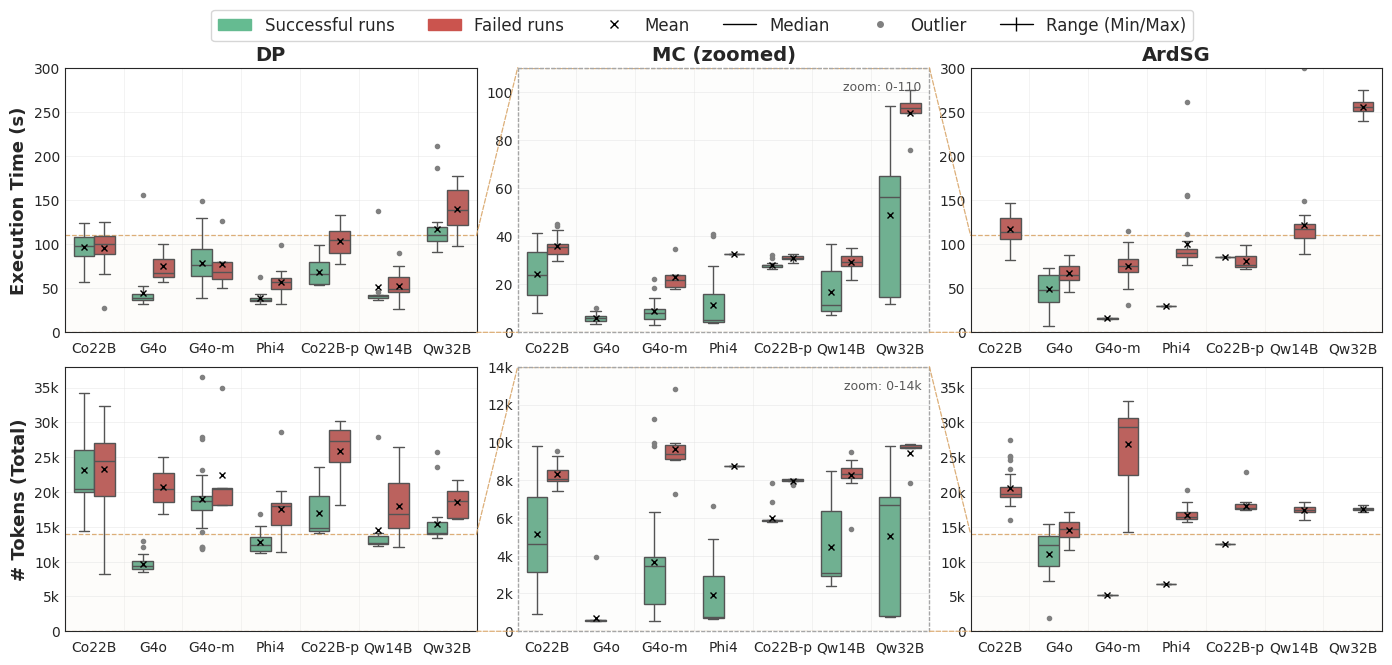

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, Rectangle

# ==========================================
# 1. SETUP & DATA
# ==========================================
required_cols = ['processor', 'model', 'status', 'latency', 'total_tokens']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

for col in ['processor', 'model', 'status']:
    df[col] = df[col].astype(str).str.strip().str.lower()

# ==========================================
# 2. CONFIGURATION
# ==========================================
MODEL_LABELS = {
    'gpt-4o': 'G4o', 'gpt-4o-mini': 'G4o-m', 'qwen32': 'Qw32B', 'qwen14': 'Qw14B',
    'phi4': 'Phi4', 'codestral': 'Co22B', 'codestral-p': 'Co22B-p'
}
PROCESSOR_LABELS = {
    'dp': 'DP',
    'mc': 'MC',
    'sg': 'ArdSG',
    'psg': 'PySG-CPU',
    'tpusg': 'PySG-TPU',
}
# Build model order from data while preserving first-seen order.
mapped_displays = [MODEL_LABELS[m] if m in MODEL_LABELS else m for m in df['model'].dropna().unique()]
MODEL_ORDER_PREF = list(dict.fromkeys(mapped_displays))
PROCESSOR_ORDER_PREF = list(PROCESSOR_LABELS.keys())

df['model_display'] = df['model'].map(MODEL_LABELS).fillna(df['model'])

metrics = [
    {'col': 'latency', 'label': 'Execution Time (s)', 'fmt': None},
    {
        'col': 'total_tokens',
        'label': '# Tokens (Total)',
        'fmt': lambda x, _: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}"
    }
]

metric_limits = {
    'latency': (0, 300),
    'total_tokens': (0, 38000),
}

mc_metric_limits = {
    'latency': (0, 110),
    'total_tokens': (0, 14000),
}

# ==========================================
# 3. STYLE TOKENS (FONTS, SIZES, WEIGHTS, COLORS)
# ==========================================
FONT = {
    'family': 'sans-serif',
    'title_size': 14,
    'title_weight': 'bold',
    'label_size': 13,
    'label_weight': 'bold',
    'legend_size': 12,
    'zoom_note_size': 9,
}

COLORS = {
    'status_success': '#65BB91',
    'status_failure': '#CB544E',
    'zoom_band': '#F5F0E6',
    'zoom_line': '#D9A66A',
    'group_separator': '0.85',
    'grid': '0.88',
    'zoom_spine': '0.65',
    'zoom_note_text': '0.35',
    'mean_marker': 'black',
    'median_line': 'black',
    'outlier': 'gray',
}

STYLE = {
    'group_separator_linewidth': 0.6,
    'group_separator_alpha': 0.35,
    'grid_linewidth': 0.6,
    'grid_alpha': 0.5,
    'box_linewidth': 1.0,
    'box_width': 0.7,
    'mean_marker_size': 5,
    'outlier_marker_size': 3,
    'zoom_linewidth': 0.9,
    'zoom_line_alpha': 0.9,
    'mc_spine_linewidth': 1.0,
    'legend_columns': 6,
}

palette = {'success': COLORS['status_success'], 'failure': COLORS['status_failure']}

# ==========================================
# 4. PLOTTING
# ==========================================
sns.set_style('white')
plt.rcParams['font.family'] = FONT['family']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(17, 7), sharey=False)
plt.subplots_adjust(top=0.915, hspace=0.13, wspace=0.1)

for col_idx, proc in enumerate(PROCESSOR_ORDER_PREF):
    subset = df[df['processor'] == proc]

    if subset.empty:
        for row_idx in range(len(metrics)):
            axes[row_idx, col_idx].set_visible(False)
        continue

    for row_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        sns.boxplot(
            data=subset,
            x='model_display',
            y=metric['col'],
            hue='status',
            hue_order=['success', 'failure'],
            order=MODEL_ORDER_PREF,
            ax=ax,
            palette=palette,
            showmeans=True,
            meanprops={
                'marker': 'x',
                'markeredgecolor': COLORS['mean_marker'],
                'markersize': STYLE['mean_marker_size']
            },
            flierprops={
                'marker': 'o',
                'markersize': STYLE['outlier_marker_size'],
                'markerfacecolor': COLORS['outlier'],
                'markeredgecolor': COLORS['outlier']
            },
            width=STYLE['box_width'],
            linewidth=STYLE['box_linewidth']
        )

        for xpos in np.arange(len(MODEL_ORDER_PREF) - 1) + 0.5:
            ax.axvline(
                x=xpos,
                color=COLORS['group_separator'],
                linewidth=STYLE['group_separator_linewidth'],
                alpha=STYLE['group_separator_alpha'],
                zorder=0
            )

        if ax.get_legend():
            ax.get_legend().remove()
        ax.set_xlabel('')
        ax.grid(
            axis='y',
            color=COLORS['grid'],
            linewidth=STYLE['grid_linewidth'],
            linestyle='-',
            alpha=STYLE['grid_alpha']
        )

        ax.set_ylabel(
            metric['label'] if col_idx == 0 else '',
            fontweight=FONT['label_weight'],
            fontsize=FONT['label_size']
        )
        ax.tick_params(axis='y', pad=0)

        if row_idx == 0:
            title = PROCESSOR_LABELS.get(proc, proc)
            if proc == 'mc':
                title += ' (zoomed)'
            ax.set_title(
                title,
                fontsize=FONT['title_size'],
                weight=FONT['title_weight'],
                pad=5
            )

        if metric['fmt']:
            ax.yaxis.set_major_formatter(FuncFormatter(metric['fmt']))

        if proc == 'mc' and metric['col'] in mc_metric_limits:
            y0, y1 = mc_metric_limits[metric['col']]
            ax.set_ylim(y0, y1)

            for spine in ax.spines.values():
                spine.set_linestyle((0, (2, 2)))
                spine.set_linewidth(STYLE['mc_spine_linewidth'])
                spine.set_color(COLORS['zoom_spine'])

            range_label = (
                f"{int(y0)}-{int(y1/1000)}k"
                if metric['col'] == 'total_tokens'
                else f"{int(y0)}-{int(y1)}"
            )
            ax.text(
                0.98,
                0.95,
                f"zoom: {range_label}",
                transform=ax.transAxes,
                ha='right',
                va='top',
                fontsize=FONT['zoom_note_size'],
                color=COLORS['zoom_note_text']
            )
        elif metric['col'] in metric_limits:
            ax.set_ylim(*metric_limits[metric['col']])

# ==========================================
# 5. ZOOM-LINK INDICATORS (MC <-> DP/ArdSG)
# ==========================================
for row_idx, metric in enumerate(metrics):
    metric_col = metric['col']
    y0, y1 = mc_metric_limits[metric_col]

    dp_ax = axes[row_idx, 0]
    mc_ax = axes[row_idx, 1]
    sg_ax = axes[row_idx, 2]

    dp_ax.axhspan(y0, y1, color=COLORS['zoom_band'], alpha=0.20, zorder=0)
    sg_ax.axhspan(y0, y1, color=COLORS['zoom_band'], alpha=0.20, zorder=0)

    mc_ax.set_facecolor(COLORS['zoom_band'])
    mc_ax.patch.set_alpha(0.10)

    for ax in [dp_ax, mc_ax, sg_ax]:
        ax.axhline(
            y=y0,
            color=COLORS['zoom_line'],
            linewidth=STYLE['zoom_linewidth'],
            linestyle='--',
            alpha=STYLE['zoom_line_alpha'],
            zorder=0
        )
        ax.axhline(
            y=y1,
            color=COLORS['zoom_line'],
            linewidth=STYLE['zoom_linewidth'],
            linestyle='--',
            alpha=STYLE['zoom_line_alpha'],
            zorder=0
        )

    for src_ax, dst_ax in [(dp_ax, mc_ax), (mc_ax, sg_ax)]:
        for y in (y0, y1):
            fig.add_artist(ConnectionPatch(
                xyA=(1.0, y), coordsA=src_ax.get_yaxis_transform(),
                xyB=(0.0, y), coordsB=dst_ax.get_yaxis_transform(),
                color=COLORS['zoom_line'],
                linewidth=STYLE['zoom_linewidth'],
                linestyle='--',
                alpha=STYLE['zoom_line_alpha']
            ))

# ==========================================
# 6. CUSTOM LEGEND
# ==========================================
legend_elements = [
    Rectangle((0, 0), 1, 1, color=palette['success'], label='Successful runs'),
    Rectangle((0, 0), 1, 1, color=palette['failure'], label='Failed runs'),
    Line2D([0], [0], color=COLORS['mean_marker'], marker='x', linestyle='None', markersize=6, label='Mean'),
    Line2D([0], [0], color=COLORS['median_line'], linewidth=1, linestyle='-', label='Median'),
    Line2D([0], [0], color=COLORS['outlier'], marker='o', linestyle='None', markersize=4, label='Outlier'),
    Line2D([0], [0], color=COLORS['median_line'], linewidth=1, linestyle='-', marker='|', markersize=10, label='Range (Min/Max)')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=STYLE['legend_columns'],
    bbox_to_anchor=(0.5, 1.01),
    fontsize=FONT['legend_size'],
    frameon=True
)

plt.savefig('figs/box_MCU.pdf', dpi=300, bbox_inches='tight')
plt.savefig('figs/box_MCU.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ==========================================
# EXPORT BOX PLOT STATISTICS
# ==========================================
# Calculate all statistics used in box plots for direct reproduction

def calculate_boxplot_stats(group_data):
    """Calculate all box plot statistics for a group"""
    if len(group_data) == 0:
        return {
            'count': 0,
            'min': None,
            'q1': None,
            'median': None,
            'q3': None,
            'max': None,
            'mean': None,
            'iqr': None,
            'lower_whisker': None,
            'upper_whisker': None,
            'outliers': None,
            'n_outliers': 0
        }
    
    q1 = group_data.quantile(0.25)
    q3 = group_data.quantile(0.75)
    iqr = q3 - q1
    
    # Calculate whiskers (1.5 * IQR rule used by matplotlib/seaborn)
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Actual whisker positions (min/max within bounds)
    within_bounds = group_data[(group_data >= lower_bound) & (group_data <= upper_bound)]
    lower_whisker = within_bounds.min() if len(within_bounds) > 0 else group_data.min()
    upper_whisker = within_bounds.max() if len(within_bounds) > 0 else group_data.max()
    
    # Outliers (outside whisker bounds)
    outliers = group_data[(group_data < lower_bound) | (group_data > upper_bound)]
    
    return {
        'count': len(group_data),
        'min': group_data.min(),
        'q1': q1,
        'median': group_data.median(),
        'q3': q3,
        'max': group_data.max(),
        'mean': group_data.mean(),
        'iqr': iqr,
        'lower_whisker': lower_whisker,
        'upper_whisker': upper_whisker,
        'outliers': outliers.tolist(),
        'n_outliers': len(outliers)
    }

# Processor labels mapping
PROCESSOR_LABELS = {
    'dp': 'DP',
    'mc': 'MC',
    'sg': 'ArdSG'
}

# Initialize list to store all statistics
all_stats = []

# Calculate statistics for each metric
metrics_to_export = [
    {'col': 'latency', 'label': 'Execution Time (s)'},
    {'col': 'total_tokens', 'label': '# Tokens (Total)'}
]

for metric in metrics_to_export:
    metric_col = metric['col']
    
    # Group by processor, model, and status
    for processor in df['processor'].unique():
        for model in df['model'].unique():
            for status in ['success', 'failure']:
                # Filter data for this combination
                subset = df[
                    (df['processor'] == processor) & 
                    (df['model'] == model) & 
                    (df['status'] == status)
                ][metric_col].dropna()
                
                # Calculate statistics
                stats = calculate_boxplot_stats(subset)
                
                # Add grouping information
                stats_record = {
                    'metric': metric_col,
                    'processor': processor,
                    'processor_label': PROCESSOR_LABELS.get(processor, processor),
                    'model': model,
                    'model_label': MODEL_LABELS.get(model, model),
                    'status': status,
                    **stats
                }
                
                all_stats.append(stats_record)

# Create DataFrame from statistics
stats_df = pd.DataFrame(all_stats)

# Filter out rows with no data
stats_df = stats_df[stats_df['count'] > 0]

# Drop outliers column for cleaner CSV
stats_df_clean = stats_df.drop(columns=['outliers'])

# Export to single CSV file
output_file = 'cost-time_statistics_MCU.csv'
stats_df_clean.to_csv(output_file, index=False)
print(f"✔ Exported all box plot statistics to: {output_file}")
print(f"  Total records: {len(stats_df_clean)}")
print(f"  Metrics included: latency, total_tokens")

# Display summary
print("\n" + "="*60)
print("STATISTICS SUMMARY")
print("="*60)
print(f"Metrics: {', '.join([m['col'] for m in metrics_to_export])}")
print(f"Processors: {', '.join(stats_df_clean['processor'].unique())}")
print(f"Models: {', '.join(stats_df_clean['model'].unique())}")
print(f"Status values: {', '.join(stats_df_clean['status'].unique())}")
print("\nColumns in exported CSV:")
for col in stats_df_clean.columns:
    print(f"  - {col}")
print("="*60)

# Display sample of statistics
print("\nSample statistics (first few rows):")
display(stats_df_clean.head(10))

✔ Exported all box plot statistics to: cost-time_statistics_MCU.csv
  Total records: 76
  Metrics included: latency, total_tokens

STATISTICS SUMMARY
Metrics: latency, total_tokens
Processors: sg, mc, dp
Models: codestral, gpt-4o, gpt-4o-mini, phi4, codestral-p, qwen14, qwen32
Status values: failure, success

Columns in exported CSV:
  - metric
  - processor
  - processor_label
  - model
  - model_label
  - status
  - count
  - min
  - q1
  - median
  - q3
  - max
  - mean
  - iqr
  - lower_whisker
  - upper_whisker
  - n_outliers

Sample statistics (first few rows):


,metric,processor,processor_label,model,model_label,status,count,min,q1,median,q3,max,mean,iqr,lower_whisker,upper_whisker,n_outliers
1,latency,sg,ArdSG,codestral,Co22B,failure,30,81.610000,105.995000,114.195000,130.185000,146.610000,117.024000,24.190000,81.610000,146.610000,0
2,latency,sg,ArdSG,gpt-4o,G4o,success,11,7.733686,34.312718,48.411749,65.161059,72.775711,48.748919,30.848342,7.733686,72.775711,0
3,latency,sg,ArdSG,gpt-4o,G4o,failure,19,45.386724,59.848777,65.306292,74.887673,87.921943,67.378662,15.038896,45.386724,87.921943,0
4,latency,sg,ArdSG,gpt-4o-mini,G4o-m,success,2,15.251896,15.500004,15.748111,15.996219,16.244326,15.748111,0.496215,15.251896,16.244326,0
5,latency,sg,ArdSG,gpt-4o-mini,G4o-m,failure,28,31.090000,68.858940,75.237158,83.639447,114.929878,74.958385,14.780507,48.970000,102.360403,2
6,latency,sg,ArdSG,phi4,Phi4,success,1,30.360000,30.360000,30.360000,30.360000,30.360000,30.360000,0.000000,30.360000,30.360000,0
7,latency,sg,ArdSG,phi4,Phi4,failure,29,76.670000,85.570000,90.350000,94.360000,260.940000,99.920345,8.790000,76.670000,103.790000,4
8,latency,sg,ArdSG,codestral-p,Co22B-p,success,1,85.380000,85.380000,85.380000,85.380000,85.380000,85.380000,0.000000,85.380000,85.380000,0
9,latency,sg,ArdSG,codestral-p,Co22B-p,failure,29,71.970000,73.910000,76.300000,86.540000,99.040000,80.423793,12.630000,71.970000,99.040000,0
11,latency,sg,ArdSG,qwen14,Qw14B,failure,30,88.490000,106.537500,117.050000,122.832500,299.850000,121.342667,16.295000,88.490000,133.470000,2
